# Real-Time Foreground Segmentation and Selective Blurring on the GPU

**CSC14116 - Applied Parallel Programming** <br>
Huỳnh Lê Hải Dương (22127081) <br>
Nguyễn Đức Tín (22127415) <br>
Repo: `github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model` <br>
**Performance was measured on a Tesla T4.** Live cells use the current machine.

**1** Introduction <br>
**2** Method <br>
**3** Evaluation <br>
**4** Discussion <br>
**5** Conclusion <br>

In [1]:
import matplotlib.pyplot as plt, numpy as np

# Palette validated for CVD safety (dataviz six-checks): identity is fixed -
# v0 blue, v1 amber, v2 red (red = the submitted version, everywhere).
C = {"v0": "#2a78d6", "v1": "#eda100", "v2": "#c0392b",
     "ink": "#1a1a19", "muted": "#8a8a85", "good": "#008300"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": .25,
    "grid.linestyle": "--", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"]})

def take(msg):
    """One bold takeaway line under a figure - the sentence to say out loud."""
    from IPython.display import display, Markdown
    display(Markdown(f"**▸ {msg}**"))

In [2]:
import os, subprocess, sys

def repo_root():
    for c in (os.getcwd(), "/content/project", os.path.join(os.getcwd(), "project")):
        if os.path.isdir(os.path.join(c, ".git")) and os.path.exists(os.path.join(c, "gmm_mask")):
            return c
    return None

root = repo_root()
if root is None:
    dest = "/content/project" if os.path.isdir("/content") else "project"
    subprocess.run(["git", "clone", "-q", "--depth", "1",
        "https://github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model.git", dest], check=True)
    root = dest
os.chdir(root); sys.path.insert(0, root)
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "numba<0.62"], capture_output=True)

import cv2, numba, platform
from numba import cuda
HAS_GPU = cuda.is_available()
base = subprocess.run(["git","rev-parse","--short","HEAD"], capture_output=True, text=True).stdout.strip()
impl_clean = subprocess.run(["git","diff","--quiet","HEAD","--",".",":(exclude)notebook.ipynb"]).returncode == 0
print(f"source commit {base} | implementation files clean: {impl_clean}")
print(f"python {platform.python_version()} | cv2 {cv2.__version__} | numba {numba.__version__} | GPU: {HAS_GPU}")

source commit 6004810 | implementation files clean: False
python 3.12.13 | cv2 5.0.0 | numba 0.61.2 | GPU: False


In [3]:
import glob, socket, urllib.request, zipfile, hashlib
socket.setdefaulttimeout(30)
HIGHWAY = os.environ.get("HIGHWAY_DIR", "highway")

def usable(d):
    return os.path.isdir(os.path.join(d, "input")) and os.path.isdir(os.path.join(d, "groundtruth"))

if not usable(HIGHWAY):
    local = glob.glob("highway.zip") + glob.glob("/content/highway.zip")
    if not local:
        # original CDnet hosts are offline; this is the team's mirror (CDnet citation on the card)
        url = ("https://huggingface.co/datasets/haiduonghuynhle/"
               "changedetection-2012-highway/resolve/main/highway.zip")
        try:
            urllib.request.urlretrieve(url, "highway.zip"); local = ["highway.zip"]
        except Exception as e:
            print("download failed:", e)
    if local:
        with zipfile.ZipFile(local[0]) as z: z.extractall(".")

HAS_DATA = usable(HIGHWAY)
os.environ["HIGHWAY_DIR"] = HIGHWAY
print("CDnet highway available:", HAS_DATA)

import numpy as np
def load_sequence(n, size=(320, 240)):
    """Frames for the figures: CDnet if present, else labelled synthetic."""
    if HAS_DATA:
        out = [cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg") for i in range(1, n + 1)]
        out = [f for f in out if f is not None]
        if out: return out, "CDnet highway"
    import bench_post
    return bench_post.make_frames(n, size), "synthetic (for illustration only)"

CDnet highway available: True


## 1 · Introduction

**Input:** fixed-camera traffic video - a stream of BGR frames (from CDnet 320×240 to real 1920×1080 footage). <br>
**Output, for each frame:** (a) a binary foreground mask - 255 for moving vehicles, 0 elsewhere; (b) a composite frame - vehicles remain sharp while all other regions receive Gaussian blur. <br>
**Goal:** produce both in real time (≥30 FPS at 1080p). Mask quality is evaluated on **CDnet `baseline/highway`** against manually annotated ground truth. The measurement uses frames 470-1700 and excludes don't-care pixels according to the CDnet procedure. <br>


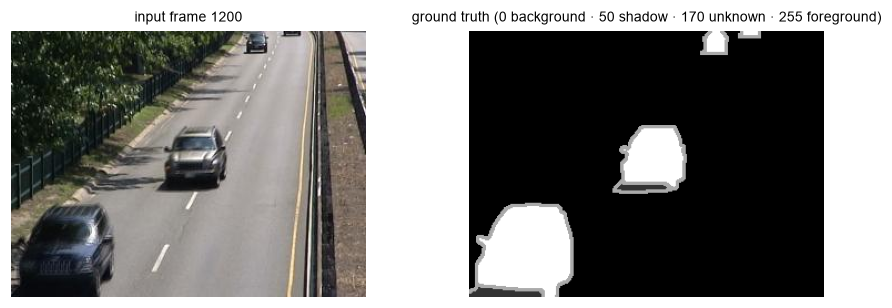

**▸ Every quality result in this notebook is scored against these manual labels.**

In [4]:
if HAS_DATA:
    i = 1200
    frame = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
    gt    = cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0)
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.9))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title(f"input frame {i}", fontsize=9)
    ax[1].imshow(gt, cmap="gray"); ax[1].set_title("ground truth (0 background · 50 shadow · 170 unknown · 255 foreground)", fontsize=9)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    take("Every quality result in this notebook is scored against these manual labels.")

### 1.1 · Why Use a GPU

| | |
|---:|---|
| **2 073 600** | pixels in each 1080p frame |
| **25 values/px → 207 MB** | model state held on the GPU and read every frame (5 Gaussians × 5 numbers, 4 bytes each) |
| **3 035 ms/frame** | sequential Python at 480p (`benchmarks/records/`) |
| **30 FPS** | real-time target |

Each pixel is updated independently, so one frame is processed by 2 million threads (small parallel work units). Only one stage does not fit this model. §2.6 explains why.

## 2 · Method

This notebook studies one algorithm - MOG2 (Zivkovic 2004), a per-pixel mixture of Gaussians - through five implementations. They are Sequential Python, Numba CPU, CUDA v0, CUDA v1, and CUDA v2. The two CPU implementations serve as a readable specification and a fair compiled baseline. The three CUDA implementations form the optimization ladder below. The entire MOG2 model is **written by the team from the paper's equations** and makes no library call inside the model. OpenCV has exactly two roles. It provides a correctness reference and a few host-side post-processing steps.

### The Algorithm in 14 Lines - `mog2_step`, Run Once per Pixel per Frame

```text
for each pixel (y, x), using one thread:
    bg_weight = 0;  matched = False
    for each Gaussian mode k = 0..K-1, always sorted by descending weight:
        dist² = ‖pixel − mean_k‖²                      # YCrCb, float32
        if dist² < Tb·var_k:                           # loose match → evidence of background
            bg_weight += w_k                           # ← the branch behind the 2-pixel story (§3.1)
            if accumulated weight < TB: pixel is background
        if not matched and dist² < Tg·var_k:           # tight match → update this mode
            matched = True
            w_k += α;  mean_k, var_k move toward pixel (rate α/w_k);  restore k to order
        w_k = (1−α)·w_k − α·CT                         # decay; remove mode below the floor
    normalize weights;  bg_prob[y,x] = bg_weight
    if not matched: replace weakest mode with (pixel, var_init, weight α)
```

| Parameter | Value (`settings.py`, = OpenCV default) | Meaning |
|---|---|---|
| K | 5 | Gaussian modes per pixel |
| α | 1/250 after warm-up (`history` 250) | learning rate - how quickly the background adapts |
| **Tb** | 16 | loose-match threshold in variance units: "close enough to count as background" |
| **Tg** | 9 | tight-match threshold: "close enough to *update* this mode" (Tb > Tg) |
| **TB** | 0.9 | accumulated weight that forms the background model |
| CT | 0.05 | prune rate - rarely observed modes are removed |
| var_init / clamp | 15, [4, 75] | variance of a new mode and its bounds |

The final output mask applies a confidence threshold: a pixel is foreground when `bg_prob < 0.5` (§2.2).

### 2.2 · Selecting the Pipeline by Measurement

We tested thirteen candidate chains in two color spaces over the full 470-1700 range.
The chart uses the committed results from `benchmarks/records/eval_highway_full.txt` directly, so every choice traces to the same record.

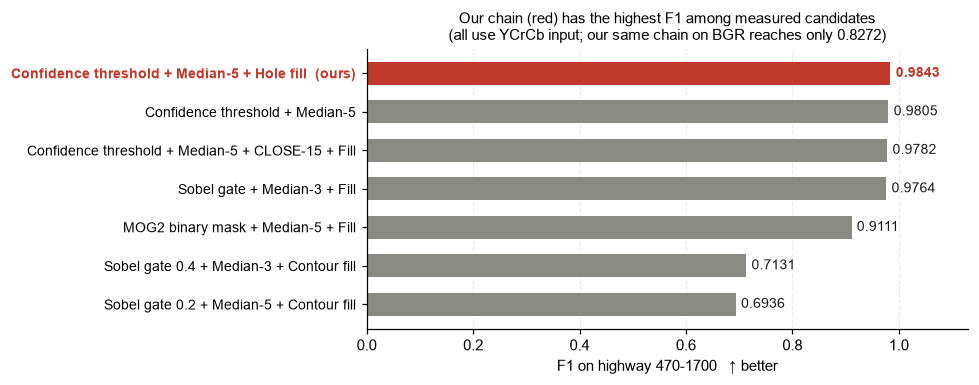

**▸ Our chain: Confidence threshold + Median-5 + Hole fill - F1 0.9843. The same chain on BGR reaches only 0.8272: color space is the largest choice.**

In [5]:
import re

def parse_record(path="benchmarks/records/eval_highway_full.txt"):
    """(colorspace, chain, F1, IoU, P, R) rows straight from the committed run."""
    rows, cs = [], None
    for line in open(path):
        m = re.match(r"highway 470-1700 .*model input = (\w+)", line.strip())
        if m: cs = m.group(1); continue
        m = re.match(r"\s{2}(\S.*?)\s{2,}([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+(\d+)\s+([\d.]+)$", line.rstrip())
        if m and cs:
            rows.append((cs, m.group(1).strip(), *map(float, m.groups()[1:5])))
    return rows

rows = parse_record()
SHIP = "bg_prob + median5 + fill"
# the chains the decision actually turned on; all 26 rows stay in the committed record
names = {r[1] for r in rows}
sobel_contour_a = next(n for n in names if n.endswith("gate.4 + med3 + contour"))
sobel_contour_b = next(n for n in names if n.endswith("gate.2 + med5 + contour+fill"))
KEY = [SHIP, "bg_prob + median5", "mask + median5 + fill",
       "sobel gate + median3 + fill", "bg_prob + median5 + close15 + fill",
       sobel_contour_a, sobel_contour_b]
f1 = {(r[0], r[1]): r[2] for r in rows}
KEY = sorted(KEY, key=lambda c: f1[("ycrcb", c)])
DISPLAY = {  # method descriptions for the axis; record keys stay as committed
    "bg_prob + median5 + fill":            "Confidence threshold + Median-5 + Hole fill  (ours)",
    "bg_prob + median5":                   "Confidence threshold + Median-5",
    "bg_prob + median5 + close15 + fill":  "Confidence threshold + Median-5 + CLOSE-15 + Fill",
    "mask + median5 + fill":               "MOG2 binary mask + Median-5 + Fill",
    "sobel gate + median3 + fill":         "Sobel gate + Median-3 + Fill",
}
DISPLAY[sobel_contour_a] = "Sobel gate 0.4 + Median-3 + Contour fill"
DISPLAY[sobel_contour_b] = "Sobel gate 0.2 + Median-5 + Contour fill"

fig, ax = plt.subplots(figsize=(9.0, 3.6))
y = np.arange(len(KEY))
vals = [f1[("ycrcb", k)] for k in KEY]
cols = [C["v2"] if k == SHIP else C["muted"] for k in KEY]
b = ax.barh(y, vals, .6, color=cols)
for k, yy, v in zip(KEY, y, vals):
    ax.text(v + .01, yy, f"{v:.4f}", va="center", fontsize=9,
            fontweight="bold" if k == SHIP else "normal",
            color=C["v2"] if k == SHIP else C["ink"])
ax.set_yticks(y)
labels = [DISPLAY.get(k, k) for k in KEY]
ax.set_yticklabels(labels, fontsize=9)
for tick, k in zip(ax.get_yticklabels(), KEY):
    if k == SHIP: tick.set_fontweight("bold"); tick.set_color(C["v2"])
ax.set_xlim(0, 1.13); ax.set_xlabel("F1 on highway 470-1700   ↑ better")
ax.set_title("Our chain (red) has the highest F1 among measured candidates\n"
             f'(all use YCrCb input; our same chain on BGR reaches only {f1[("bgr", SHIP)]:.4f})',
             fontsize=10)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

take(f'Our chain: Confidence threshold + Median-5 + Hole fill - F1 {f1[("ycrcb", SHIP)]:.4f}. '
     f'The same chain on BGR reaches only {f1[("bgr", SHIP)]:.4f}: color space is the largest choice.')

**The measurements changed three of our initial choices:**

- **Remove morphological CLOSE.** It fills holes by expanding the mask, which can join nearby vehicles across the road surface. Precision falls from `0.9863 → 0.9634`, while **F1 moves by only 0.006**. The aggregate score therefore hides a visible shape error.
- **Remove the alternative contour-fill chain.** This combination reaches only **0.55** precision and fills the road between vehicles. The result does not isolate contour fill as the sole cause, but it is sufficient to reject the full chain for release.
- **Use a confidence threshold instead of MOG2's direct decision.** MOG2 marks background after *any* match. Requiring at least half of the total weight gives **+7 F1**, so confidence carries more useful information than the early binary decision.
- **The Sobel edge-gate variant deserved testing:** in raw form, it beats raw bg_prob (0.9102 versus 0.9098). However, its best full chain reaches only 0.9764 versus 0.9843 for the shipping chain, while contour-fill variants fall to 0.71/0.69. Measurement, not preference, determined the final choice.

### 2.3 · Optimization Ladder: Accelerating the Chosen Pipeline

| Version | Level | Change |
|---|---|---|
| **v0** | L1 naive port | model kernel (a parallel GPU function), one thread per pixel. Correct, but every remaining stage still runs on the host. |
| **v1** | L2 memory | reduce frame upload from 12 to 3 B/px; move integer YCrCb conversion, threshold, median, blur, and composite to the device - the mask no longer makes a round trip across the bus |
| **v2** | L2 + L3 | fuse threshold into the end of the model kernel (one fewer launch and full-frame pass); rebuild median and blur with shared-memory tiles (fast on-chip data blocks) |

The next three sections describe what each version adds and which technique it uses.

*The next three sections zoom into the ladder's three key decisions: data over the bus (v1), the integer blur (v1/v2), and the stage left on the CPU (every version).*

#### v0 - Naive Port: Move the Model Kernel to the GPU
- **What it adds:** The model kernel runs one thread per pixel. Each block contains 32×8 = 256 threads, with x axis = 32 to match warp size. Ceiling-divided grids cover the frame.
- **Technique:** State uses a planar `(K, C, H, W)` layout. Adjacent threads therefore read adjacent bytes and achieve coalesced access, which combines several reads into one memory transaction.
- **Limit:** Every other stage remains on the host. Frames upload as float32 at 12 B/px, and both the mask and confidence map must download every frame. v1 targets this data movement directly.

#### v1 - Reduce Data Movement and Move Post-Processing to Kernels
- **What it adds:** This implementation adds an integer YCrCb conversion kernel, threshold kernel, 5×5 median kernel, and blur + composite kernel pair. All post-processing except fill runs on the device.
- **Technique:** *Transfer reduction* uploads uint8 at 3 B/px instead of float32 at 12 B/px, avoids downloading the confidence map, and keeps the mask on the device until fill. These changes reduce bus traffic from 35.25 → 16.59 MB/frame. Vertical blur is fused with composite to remove one full-frame write/read pass.

#### v2 - Kernel Fusion and Shared-Memory Tiling
- **What it adds:** Threshold is fused into the end of the model kernel, so 3 kernels become 2. Median and blur are rewritten with shared-memory tiles. Each tile loads an image block plus its halo into on-chip memory, so each pixel is read from global memory only once per block.
- **Technique:** Fusion is placed on the bandwidth-heavy side, so median reads a 1 B/px mask instead of a 4 B/px `bg_prob`. Tiling removes repeated reads for the 25-point median neighborhood and 15-point blur neighborhood. Measurement shows a 2.36× speedup.
- **Boundary:** Median is not fused into the model kernel. Recomputing the halo would apply state updates twice, causing an algorithmic error rather than exposing an optimization omission.

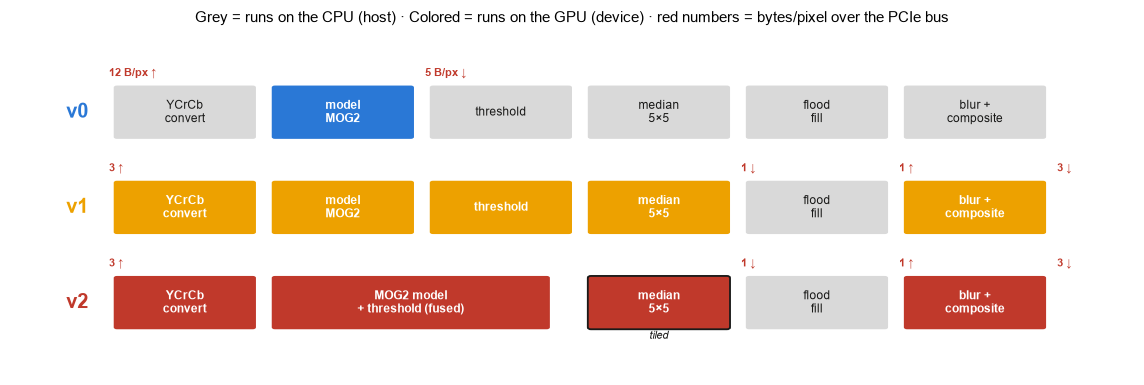

**▸ v1 moves almost the whole pipeline onto the GPU and cuts bus traffic; v2 fuses kernels and tiles median/blur. Flood fill stays on the CPU in every version.**

In [6]:
# Diagram: which stage runs where, per implementation
import matplotlib.patches as mpatches

STAGES = ["YCrCb\nconvert", "model\nMOG2", "threshold", "median\n5×5", "flood\nfill", "blur +\ncomposite"]
GPU = {"v0": {1}, "v1": {0, 1, 2, 3, 5}, "v2": {0, 1, 2, 3, 5}}
FUSED = {"v2": (1, 2)}                    # model + threshold gộp làm một kernel
BUS = {"v0": {0: "12 B/px ↑", 2: "5 B/px ↓"},
       "v1": {0: "3 ↑", 4: "1 ↓", 5: "1 ↑", 6: "3 ↓"},
       "v2": {0: "3 ↑", 4: "1 ↓", 5: "1 ↑", 6: "3 ↓"}}

fig, ax = plt.subplots(figsize=(10.5, 3.6))
for r, v in enumerate(("v0", "v1", "v2")):
    yy = 2 - r
    ax.text(-.75, yy, v, fontsize=13, fontweight="bold", va="center", color=C[v])
    skip = FUSED.get(v, ())
    for s, name in enumerate(STAGES):
        if v in FUSED and s == FUSED[v][1]:
            continue                      # đã gộp vào box trước
        w = 1.72 if (v in FUSED and s == FUSED[v][0]) else .86
        label = "MOG2 model\n+ threshold (fused)" if w > 1 else name
        on_gpu = s in GPU[v]
        ax.add_patch(mpatches.FancyBboxPatch((s - .43, yy - .26), w, .52,
            boxstyle="round,pad=0.02", linewidth=1.2,
            facecolor=(C[v] if on_gpu else "#d9d9d9"),
            edgecolor=(C["ink"] if s == 3 and v == "v2" else "none")))
        ax.text(s - .43 + w/2, yy, label, ha="center", va="center", fontsize=7.6,
                color="white" if on_gpu else C["ink"],
                fontweight="bold" if on_gpu else "normal")
    if v == "v2":
        ax.text(3, yy - .38, "tiled", ha="center", fontsize=7, style="italic", color=C["ink"])
    for pos, lbl in BUS[v].items():
        ax.text(pos - .48, yy + .38, lbl, fontsize=7.5, color=C["v2"], fontweight="bold")
ax.set_xlim(-1.1, 6.0); ax.set_ylim(-.75, 2.85)
ax.axis("off")
ax.set_title("Grey = runs on the CPU (host) · Colored = runs on the GPU (device) · red numbers = bytes/pixel over the PCIe bus",
             fontsize=10)
plt.tight_layout(); plt.show()

take("v1 moves almost the whole pipeline onto the GPU and cuts bus traffic; "
     "v2 fuses kernels and tiles median/blur. Flood fill stays on the CPU in every version.")

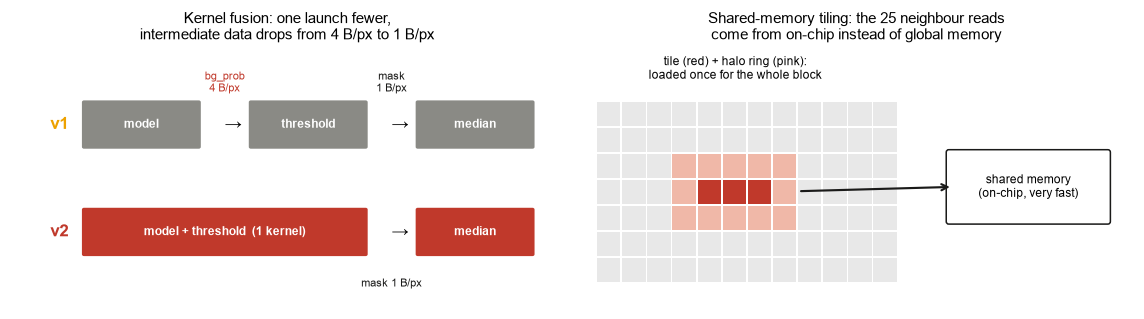

In [7]:
# The two techniques that define v2, drawn simply
import matplotlib.patches as mpatches
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.0))

# --- trái: kernel fusion
def box(ax, x, y, w, txt, fc, tc="white"):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, .5, boxstyle="round,pad=0.02",
                                         facecolor=fc, edgecolor="none"))
    ax.text(x + w/2, y + .25, txt, ha="center", va="center", fontsize=8, color=tc, fontweight="bold")
box(a1, 0, 1.5, 1.1, "model", C["muted"]); box(a1, 1.6, 1.5, 1.1, "threshold", C["muted"])
box(a1, 3.2, 1.5, 1.1, "median", C["muted"])
a1.text(1.35, 1.75, "→", fontsize=11, va="center"); a1.text(2.95, 1.75, "→", fontsize=11, va="center")
a1.text(1.35, 2.12, "bg_prob\n4 B/px", ha="center", fontsize=7, color=C["v2"])
a1.text(2.95, 2.12, "mask\n1 B/px", ha="center", fontsize=7, color=C["ink"])
box(a1, 0, .3, 2.7, "model + threshold  (1 kernel)", C["v2"])
box(a1, 3.2, .3, 1.1, "median", C["v2"])
a1.text(2.95, .55, "→", fontsize=11, va="center")
a1.text(2.95, -.06, "mask 1 B/px", ha="center", fontsize=7, color=C["ink"])
a1.text(-.15, 1.75, "v1", fontsize=11, fontweight="bold", va="center", ha="right", color=C["v1"])
a1.text(-.15, .55, "v2", fontsize=11, fontweight="bold", va="center", ha="right", color=C["v2"])
a1.set_xlim(-.7, 4.6); a1.set_ylim(-.3, 2.6); a1.axis("off")
a1.set_title("Kernel fusion: one launch fewer,\nintermediate data drops from 4 B/px to 1 B/px", fontsize=9.5)

# --- phải: shared-memory tile + halo
for gx in range(12):
    for gy in range(7):
        a2.add_patch(mpatches.Rectangle((gx*.3, gy*.3), .28, .28, facecolor="#e8e8e8"))
for gx in range(3, 8):
    for gy in range(2, 5):
        halo = gx in (3, 7) or gy in (2, 4)
        a2.add_patch(mpatches.Rectangle((gx*.3, gy*.3), .28, .28,
                     facecolor="#f0b8a8" if halo else C["v2"]))
a2.add_patch(mpatches.FancyBboxPatch((4.2, .7), 1.9, .8, boxstyle="round,pad=0.03",
             facecolor="white", edgecolor=C["ink"]))
a2.text(5.15, 1.1, "shared memory\n(on-chip, very fast)", ha="center", va="center", fontsize=8)
a2.annotate("", xy=(4.25, 1.1), xytext=(2.4, 1.05),
            arrowprops=dict(arrowstyle="->", lw=1.4, color=C["ink"]))
a2.text(1.65, 2.35, "tile (red) + halo ring (pink):\nloaded once for the whole block", ha="center", fontsize=8)
a2.set_xlim(-.2, 6.4); a2.set_ylim(-.3, 2.7); a2.axis("off")
a2.set_title("Shared-memory tiling: the 25 neighbour reads\ncome from on-chip instead of global memory", fontsize=9.5)
plt.tight_layout(); plt.show()

In [8]:
# Recorded on a Colab Tesla T4 (RESULTS-T4.md, benchmarks/records/). Quoted, because charts need a
# GPU-measured input and this notebook must render on a CPU-only machine too.
SIZES = ["480p", "720p", "1080p"]
T4 = {"v0": {"ms": [10.22, 20.82, 55.03], "fps": [97.9, 48.0, 18.2]},
      "v1": {"ms": [3.74, 6.98, 13.75],   "fps": [267.3, 143.3, 72.8]},
      "v2": {"ms": [3.26, 6.02, 11.26],   "fps": [307.1, 166.2, 88.8]}}
BUS = {"v0": [6.97, 15.67, 35.25], "gpu": [3.28, 7.37, 16.59]}
PERSTAGE = {  # ms/frame per stage, [480p, 720p, 1080p]
    "v0": {"mask production": [6.278, 12.302, 35.924], "host fill_holes": [0.965, 2.155, 4.622],
           "blur + composite": [3.385, 6.333, 14.383]},
    "v1": {"mask production": [1.175, 1.940, 3.651],   "host fill_holes": [0.877, 1.938, 4.441],
           "blur + composite": [1.616, 3.083, 6.057]},
    "v2": {"mask production": [1.149, 1.984, 3.510],   "host fill_holes": [0.882, 1.972, 4.719],
           "blur + composite": [1.108, 2.044, 3.665]}}
# Measured 2026-08-21 on a Colab T4 at commit 786b54b - one session for all five
# implementations, real 1080p traffic clip (Pexels 4791721), decode excluded.
# Record: benchmarks/records/t4_final_run2.txt. numba..v2: 152 timed frames;
# sequential: 8/6/4/3 frames (it is slow), same decode and same full pipeline.
REALFOOTAGE_T4 = {
    "tiers": ["240p", "480p", "720p", "1080p"],
    "seq":   {"ms": [893.9, 4327.1, 9708.6, 21725.2], "fps": [1.12, 0.23, 0.10, 0.05]},
    "numba": {"ms": [6.11, 35.08, 64.47, 133.03], "fps": [164, 29, 16, 8]},
    "v0":    {"ms": [4.42, 10.83, 22.23, 54.71],  "fps": [226, 92, 45, 18]},
    "v1":    {"ms": [1.42, 3.90, 6.66, 13.41],    "fps": [706, 256, 150, 75]},
    "v2":    {"ms": [1.30, 3.39, 5.57, 11.24],    "fps": [769, 295, 179, 89]},
}

### 2.4 · Decision 1: Halving Bus Traffic

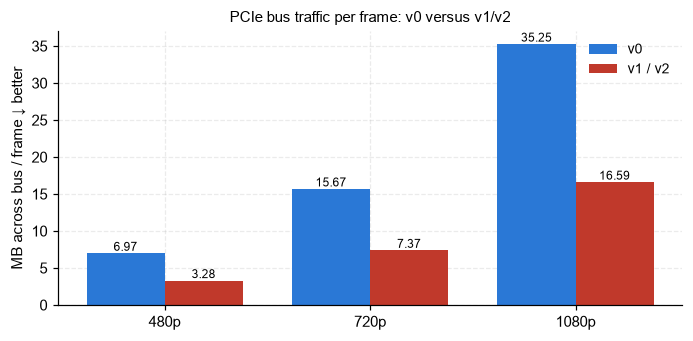

**▸ At 1080p: 35.25 → 16.59 MB per frame. Frames upload as 3 bytes per pixel instead of 12, and the confidence map is no longer downloaded.**

In [9]:
x = np.arange(3)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
b1 = ax.bar(x - .19, BUS["v0"], .38, label="v0", color=C["v0"])
b2 = ax.bar(x + .19, BUS["gpu"], .38, label="v1 / v2", color=C["v2"])
ax.bar_label(b1, fmt="%.2f", fontsize=8); ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(SIZES); ax.set_ylabel("MB across bus / frame ↓ better")
ax.legend(frameon=False, fontsize=9)
ax.set_title("PCIe bus traffic per frame: v0 versus v1/v2", fontsize=9.5)
plt.tight_layout(); plt.show()
take(f"At 1080p: {BUS['v0'][2]} → {BUS['gpu'][2]} MB per frame. Frames upload as "
     f"3 bytes per pixel instead of 12, and the confidence map is no longer downloaded.")

- **How to read:** Each bar represents the bytes crossing the PCIe bus (host ↔ GPU) per frame. Lower bars mean less transfer overhead.
- **Look for:** At 1080p, v0 transfers 35.25 MB per frame, while v1/v2 transfer only 16.59 MB. This is less than half and substantially reduces bus load.
- **Conclusion:** v1 gains by moving *less* data. It uploads 3 B/px, avoids downloading the confidence map, and keeps the mask on the device until fill to avoid a round trip.

### 2.5 · Decision 2: A Bit-Exact Integer Blur

Every image in the pipeline is `uint8` - each color channel is an integer in 0..255. We planned a separable Gaussian blur with float coefficients, then discovered: **on `uint8` input, `cv2.GaussianBlur` does not multiply by real coefficients.** It converts the 15 Gaussian weights into 15 integers summing to exactly 256 (rounded *cumulatively*, not per weight), does all the arithmetic in integers, and divides by 256 once at the end. Our GPU blur kernel reimplements exactly that integer path - matching cv2 bit for bit requires reproducing its arithmetic.

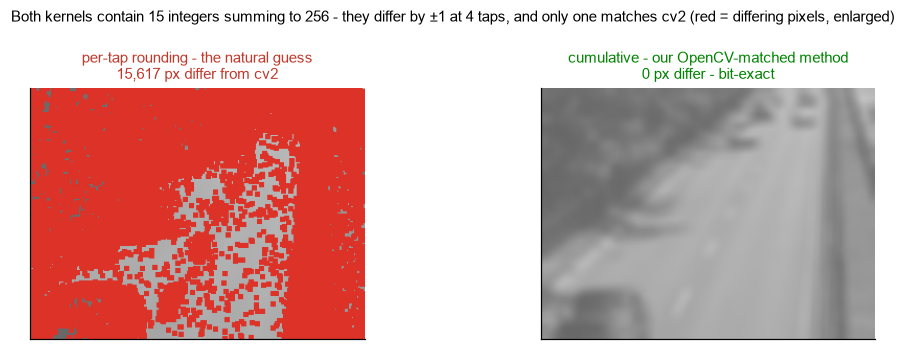

**▸ Our fixed-point pipeline: 0 of 230,400 channel values differ from cv2. The *exact* float64 Gaussian differs on 14.8% - this deviation belongs to OpenCV and must be inherited for parity.**

In [10]:
from gmm_mask.gpu.blur_kernels import gaussian_kernel_q8, blur_reference
from settings import BLUR_KSIZE, BLUR_SIGMA

k   = cv2.getGaussianKernel(BLUR_KSIZE, BLUR_SIGMA).ravel()
KQ  = gaussian_kernel_q8()                       # cumulative - what OpenCV does
per = np.rint(k * 256).astype(KQ.dtype)          # per-tap - the obvious guess

# blur ONE real frame both ways and compare each result with cv2, pixel by pixel
img = (cv2.imread(f"{HIGHWAY}/input/in000700.jpg") if HAS_DATA
       else np.random.default_rng(0).integers(0, 256, (240, 320, 3), np.uint8))
ref = cv2.GaussianBlur(img, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
show = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
DIL = np.ones((5, 5), np.uint8)                  # differences enlarged for visibility

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, kern, name, col in [(axes[0], per, "per-tap rounding - the natural guess", C["v2"]),
                            (axes[1], KQ,  "cumulative - our OpenCV-matched method",  C["good"])]:
    d = (blur_reference(img, kern) != ref).any(axis=2)
    n = int(d.sum())
    overlay = np.stack([show]*3, -1) // 2 + 96
    overlay[cv2.dilate(d.astype(np.uint8), DIL) > 0] = [220, 50, 40]
    ax.imshow(overlay); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\n{n:,} px differ from cv2" if n else
                 f"{name}\n0 px differ - bit-exact", fontsize=9.5, color=col)
fig.suptitle("Both kernels contain 15 integers summing to 256 - they differ by ±1 at 4 taps, "
             "and only one matches cv2 (red = differing pixels, enlarged)", fontsize=9.5)
plt.tight_layout(); plt.show()

rng = np.random.default_rng(0); bad = tot = 0
for s in range(4):
    t = rng.integers(0, 256, (120, 160, 3), dtype=np.uint8)
    d = blur_reference(t, KQ) != cv2.GaussianBlur(t, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
    bad += int(d.sum()); tot += d.size
ideal = np.floor(cv2.sepFilter2D(t.astype(np.float64), cv2.CV_64F, k, k,
                 borderType=cv2.BORDER_REFLECT_101) + .5).astype(np.uint8)
gap = (np.abs(ideal.astype(int) - blur_reference(t, KQ).astype(int)) != 0).mean()
take(f"Our fixed-point pipeline: {bad} of {tot:,} channel values differ from cv2. "
     f"The *exact* float64 Gaussian differs on {gap:.1%} - this deviation belongs to OpenCV and must be inherited for parity.")

*The GPU blur is also written by the team as an integer kernel. `cv2.GaussianBlur` in the cell above is only the target to match and is not part of the pipeline.*

**What is Q8 fixed-point?** Instead of multiplying by a real coefficient (for example, 0.0596), multiply by an integer (15) and divide by 256 at the final step - "Q8" means a fixed denominator of 2⁸ = 256. The entire blur then uses only integer addition and multiplication.

- The natural per-tap guess differs from OpenCV at **15,617 pixels** in the displayed frame, while the cumulative Q8 kernel matches. Integer arithmetic then produces the same result on every machine and compiler. Verification on both ARM and x86 found **0 differing pixels across all 4 OpenCV builds**.
- Floating point cannot guarantee this property. With the same formula, two compilers may differ in the last bit. That difference is exactly the source of the 2-pixel float32 model-kernel result.

**Conclusion:** using integers at a stage buys *exact* correctness for that stage. The parity gate therefore requires zero-tolerance matches for integer stages, while floating-point stages only need evidence that differences occur at the boundary.

### 2.6 · Decision 3: The Stage Kept on the CPU

OpenCV's `fill_holes` uses scan-line flood fill (filling regions row by row), which is inherently sequential. One parallel alternative repeatedly dilates each pixel inward from the boundary. The practical question is whether its cost justifies moving it to the GPU.

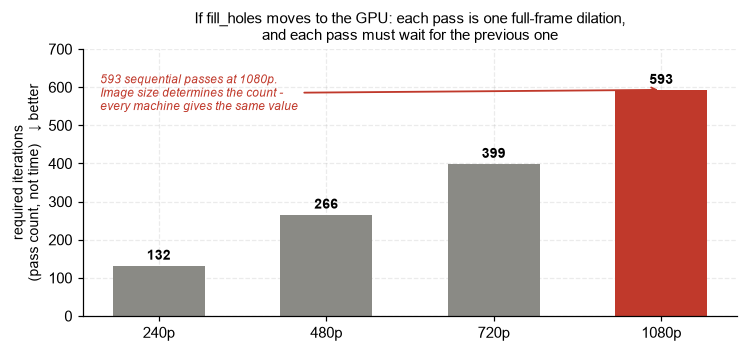

**▸ Even if CUDA dilation is one hundred times faster, all 593 sequential passes must still run. Identifying a stage that should NOT move to the GPU is also a result.**

In [11]:
PASSES = {"240p": 132, "480p": 266, "720p": 399, "1080p": 593}
fig, ax = plt.subplots(figsize=(6.9, 3.3))
cols = [C["muted"]]*3 + [C["v2"]]
b = ax.bar(list(PASSES), list(PASSES.values()), .55, color=cols)
ax.bar_label(b, fmt="%d", fontsize=9, fontweight="bold", padding=2)
ax.set_ylabel("required iterations\n(pass count, not time)   ↓ better", fontsize=9)
ax.set_ylim(0, 700)
ax.set_title("If fill_holes moves to the GPU: each pass is one full-frame dilation,\n"
             "and each pass must wait for the previous one", fontsize=10)
ax.annotate("593 sequential passes at 1080p.\nImage size determines the count -\nevery machine gives the same value",
            xy=(3, 593), xytext=(-0.35, 540), fontsize=8, style="italic", color=C["v2"],
            arrowprops=dict(arrowstyle="->", color=C["v2"], lw=1.2))
plt.tight_layout(); plt.show()

take("Even if CUDA dilation is one hundred times faster, all 593 sequential passes must still run. "
     "Identifying a stage that should NOT move to the GPU is also a result.")

*For each size, we used a synthetic mask with a fixed seed and measured timing on the CPU. We did not build a CUDA reconstruction. This result only shows that this implementation requires hundreds of dependent passes. It does not claim that every parallel flood fill is slow.*

This is the course's **Partial GPU Principle**: *"identify one or two operations that dominate runtime and accelerate those operations - do not rewrite the entire application."* In this pipeline, measurement supports keeping flood fill on the CPU. This stage is not overlooked work.

## 3 · Evaluation

### 3.1 · Parity Across Implementations

Correctness first, speed second. On synthetic sequences, parity (matching outputs across implementations) gives bit-identical masks. Across 1231 real frames, **only 2 pixels differ among 94.5 million pixels**. Each case was demonstrated separately in the record `benchmarks/records/t4_final_run.txt`. One pixel lies exactly at the 0.5 threshold, with values of 0.4999971 versus 0.5000015. The other comes from a comparison that two compilers round one ulp apart, which is the smallest float step. The verdict for both v1 and v2 is **FLOAT-BOUNDARY**. Every integer stage is bit-exact with zero tolerance.

⏱ *The live cell runs only `tests/test_parity.py`. The full test suite recorded 75 passed on T4 at `786b54b`.*

In [12]:
r = subprocess.run([sys.executable,"-m","pytest","tests/test_parity.py","-q","--no-header",
                    "-p","no:cacheprovider"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])
if HAS_GPU:
    take("Synthetic parity tests passed on this GPU; the real-video scan is reported separately.")
else:
    take("This local run checks only CPU paths; the committed T4 record provides GPU evidence.")

5 passed, 11 skipped in 0.78s


**▸ This local run checks only CPU paths; the committed T4 record provides GPU evidence.**

### 3.2 · Correctness Against OpenCV MOG2

We do not use OpenCV's MOG2 because the algorithm is reimplemented from scratch. This check runs our implementation side by side with the library's over 120 frames, then compares the masks pixel by pixel. In this run, **3 px out of 9 216 000 (0.00003%)** differ. No growing divergence is observed across those frames. This figure does not reuse the GPU-parity result from §3.1, so it provides an independent source of evidence.

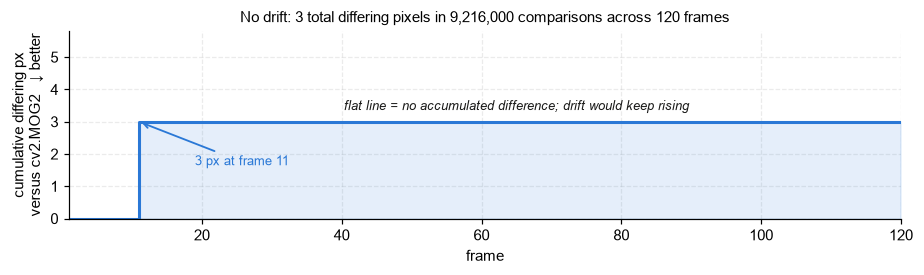

**▸ The curve jumps once and then stays flat: the difference does not accumulate - our implementation does not drift farther from OpenCV.**

In [13]:
from gmm_mask import GMM_Mask_Numba
from settings import (MOG2_HISTORY, MOG2_VAR_THRESHOLD, MOG2_N_COMPONENTS,
                      MOG2_BACKGROUND_RATIO)

if HAS_DATA:
    ours = None
    cvm = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm.setNMixtures(int(MOG2_N_COMPONENTS)); cvm.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    per_frame = []
    for i in range(1, 121):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        if ours is None: ours = GMM_Mask_Numba(*bgr.shape[:2])
        m, _, _ = ours.apply(np.ascontiguousarray(bgr, np.float32))
        per_frame.append(int((np.asarray(m) != cvm.apply(bgr)).sum()))

    px = 120 * bgr.shape[0] * bgr.shape[1]
    cum = np.cumsum(per_frame)
    fig, ax = plt.subplots(figsize=(8.5, 2.6))
    ax.step(range(1, 121), cum, where="post", color=C["v0"], lw=2)
    ax.fill_between(range(1, 121), cum, step="post", color=C["v0"], alpha=.12)
    first = next(f for f, n in enumerate(per_frame, 1) if n)
    ax.annotate(f"{per_frame[first-1]} px at frame {first}", xy=(first, cum[first-1]),
                xytext=(first + 8, cum[first-1] * .55), fontsize=8.5, color=C["v0"],
                arrowprops=dict(arrowstyle="->", color=C["v0"], lw=1.2))
    ax.text(65, cum[-1] * 1.12, "flat line = no accumulated difference; drift would keep rising",
            fontsize=8.5, style="italic", color=C["ink"], ha="center")
    ax.set_xlim(1, 120); ax.set_ylim(0, cum[-1] * 1.6 + 1)
    ax.set_xlabel("frame")
    ax.set_ylabel("cumulative differing px\nversus cv2.MOG2   ↓ better")
    ax.set_title(f"No drift: {cum[-1]} total differing pixels in {px:,} comparisons across 120 frames",
                 fontsize=10)
    plt.tight_layout(); plt.show()
    take("The curve jumps once and then stays flat: the difference does not accumulate - "
         "our implementation does not drift farther from OpenCV.")


- **How to read:** The curve shows the cumulative pixels where our mask differs from the cv2 mask across 120 frames. Continued growth would indicate accumulating divergence.
- **Look for:** The curve jumps once by 3 px at frame 11, then stays flat for the remaining 110 frames. There are no later jumps.
- **Conclusion:** The difference does not accumulate over time, so our implementation does not drift farther from OpenCV. This is a local deviation, not a propagating state error.

### 3.3 · Comparing the Mask with Labels

First, score three frames. Then place one fixed frame beside OpenCV to make the post-processing difference visible.

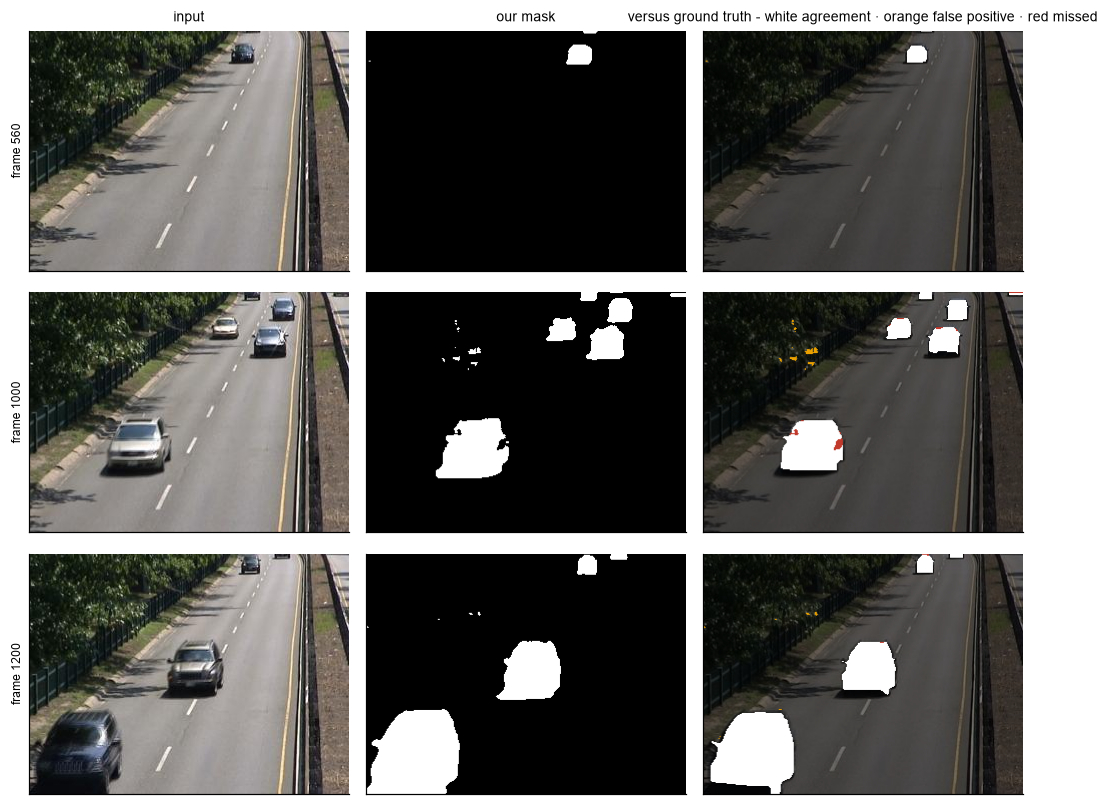

**▸ Errors lie on object boundaries and shadows, not across entire vehicles.**

In [14]:
from utils.post_processing import refine_mask, fill_holes, threshold_bg_prob

if HAS_DATA:
    m = GMM_Mask_Numba(240, 320)
    keep, want = {}, [560, 1000, 1200]
    for i in range(1, max(want) + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        if i in want:
            keep[i] = (bgr.copy(),
                       refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob)),
                       cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0))

    fig, axes = plt.subplots(len(want), 3, figsize=(9.5, 2.5 * len(want)))
    for row, i in zip(axes, want):
        bgr, ours_m, gt = keep[i]
        valid = (gt == 255) | (gt == 0)
        ok = (ours_m == 255) & (gt == 255)
        fp = (ours_m == 255) & (gt == 0)
        fn = (ours_m == 0) & (gt == 255)
        overlay = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(float) * .45
        overlay[ok] = [255, 255, 255]           # agreement
        overlay[fp] = [235, 161, 0]             # we say fg, label says bg
        overlay[fn] = [192, 57, 43]             # we miss it
        row[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); row[0].set_ylabel(f"frame {i}", fontsize=8)
        row[1].imshow(ours_m, cmap="gray")
        row[2].imshow(overlay.astype(np.uint8))
        for a in row: a.set_xticks([]); a.set_yticks([])
    axes[0][0].set_title("input", fontsize=9)
    axes[0][1].set_title("our mask", fontsize=9)
    axes[0][2].set_title("versus ground truth - white agreement · orange false positive · red missed", fontsize=9)
    plt.tight_layout(); plt.show()
    take("Errors lie on object boundaries and shadows, not across entire vehicles.")

- **How to read:** White represents agreement with the label, orange represents foreground marked over labeled background, and red represents missed foreground. These colors separate error types instead of showing only one F1 score.
- **Look for:** Colored errors cluster around object boundaries and shadows rather than covering an entire vehicle. The main vehicle shapes remain intact.
- **Conclusion:** At F1 0.9843, the remaining errors are mainly boundary pixels rather than missed vehicles. They therefore have little effect on the goal of keeping vehicles sharp.

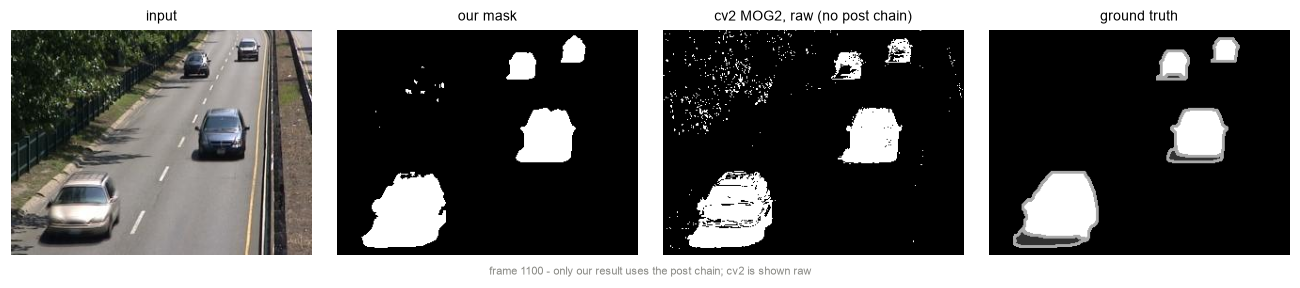

**▸ Numba represents all five implementations here: synthetic parity covers all of them, while recorded real-frame parity for CUDA v1/v2 differs only at the 2 demonstrated float-boundary pixels.**

In [15]:
# One fixed frame, judged three ways: our shipping chain, OpenCV's MOG2, the label.
# Fresh models, warmed together from frame 1 - equal model age, each fed its own
# documented input (ours YCrCb, cv2 BGR); the post chain is applied to ours only.
if HAS_DATA:
    F = 1100
    ours2 = GMM_Mask_Numba(240, 320)
    cvm2 = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm2.setNMixtures(int(MOG2_N_COMPONENTS)); cvm2.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    for i in range(1, F + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = ours2.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        cv_mask = cvm2.apply(bgr)
    ours_m = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
    gt = cv2.imread(f"{HIGHWAY}/groundtruth/gt{F:06d}.png", 0)
    panels = [("input", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
              ("our mask", ours_m),
              ("cv2 MOG2, raw (no post chain)", cv_mask),
              ("ground truth", gt)]
    fig, ax = plt.subplots(1, 4, figsize=(12, 2.6))
    for a, (t, im) in zip(ax, panels):
        a.imshow(im, cmap=None if im.ndim == 3 else "gray")
        a.set_title(t, fontsize=9); a.axis("off")
    fig.suptitle(f"frame {F} - only our result uses the post chain; cv2 is shown raw", fontsize=7.5, y=.02, color=C["muted"])
    plt.tight_layout(); plt.show()
    take("Numba represents all five implementations here: synthetic parity covers all of them, "
         "while recorded real-frame parity for CUDA v1/v2 differs only at the 2 demonstrated float-boundary pixels.")

- **How to read:** The same frame passes through our full chain and raw cv2 MOG2 (without a post chain), after which both results are compared with the manual label. The three columns isolate the effect of post-processing.
- **Look for:** Our chain produces solid, connected vehicle shapes, while the library's raw mask still has holes and speckle noise. The label provides a visual reference.
- **Conclusion:** One CPU model represents all five implementations in this figure because synthetic parity covers them. On real frames, parity differs only at the 2 demonstrated boundary pixels.

### 3.4 · Throughput on Synthetic Frames

These are recorded T4 performance measurements - the same empirical data used to check every prediction in §4.1.

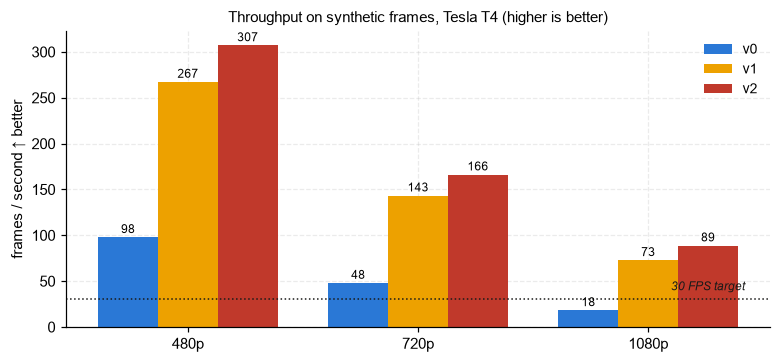

**▸ 88.8 FPS at 1080p - 4.89× the v0 baseline and 2.9× the 30 FPS target. The other proposal target, >20× over Sequential Python, reaches 887× at 480p (RESULTS-T4 §3: sequential 3 034.62 ms/frame).**

In [16]:
x = np.arange(3); w = .26
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for i, v in enumerate(("v0", "v1", "v2")):
    b = ax.bar(x + (i-1)*w, T4[v]["fps"], w, label=v, color=C[v])
    ax.bar_label(b, fmt="%.0f", fontsize=8, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(2.42, 40, "30 FPS target", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(x); ax.set_xticklabels(SIZES)
ax.set_ylabel("frames / second ↑ better")
ax.set_title("Throughput on synthetic frames, Tesla T4 (higher is better)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

sp = T4["v0"]["ms"][2] / T4["v2"]["ms"][2]
take(f"88.8 FPS at 1080p - {sp:.2f}× the v0 baseline and 2.9× the 30 FPS target. "
     "The other proposal target, >20× over Sequential Python, reaches 887× "
     "at 480p (RESULTS-T4 §3: sequential 3 034.62 ms/frame).")

- **How to read:** Each bar represents frames processed per second on synthetic data. The dotted line is the real-time target of 30 FPS, so bars above it meet the requirement.
- **Look for:** v2 reaches 88.8 FPS at 1080p, which is 4.89× v0 and 2.9× the target. The gap remains clear at the largest resolution.
- **Conclusion:** Both proposal goals are met. The system reaches 30 FPS at 1080p and >20× over Sequential Python, specifically 887× at 480p under the same measurement procedure.

### 3.5 · Throughput on Real Footage

### What Each Implementation Adds - One Session, Real 1080p Footage

| Implementation | ms per frame | FPS |
|---|---|---|
| Sequential Python | 21 725.2 | 0.05 |
| Numba CPU | 133.03 | 8 |
| CUDA v0 | 54.71 | 18 |
| CUDA v1 | 13.41 | 75 |
| CUDA v2 | **11.24** | **89** |

*All five implementations were evaluated in one Colab T4 session. The session record is `benchmarks/records/t4_final_run2.txt`. The two figures below plot these exact values.*

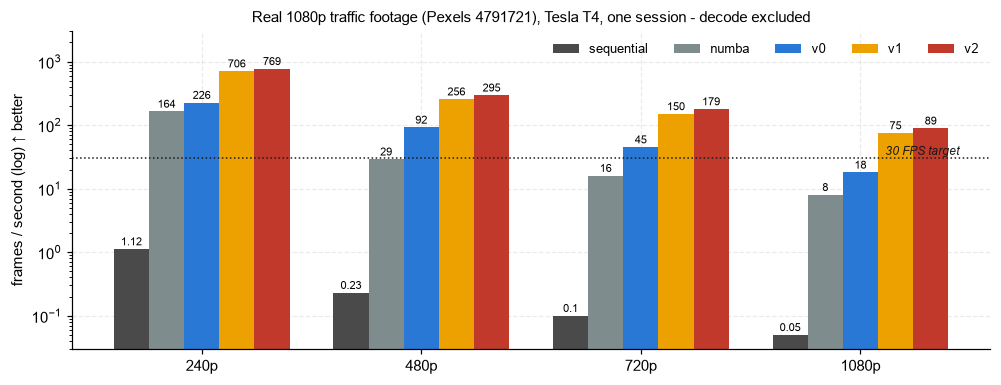

**▸ 89 FPS at 1080p on real footage - 4.9× v0, 11.8× the compiled CPU and 1,933× Sequential Python; all measured on the same clip in the same session.**

In [17]:
# The referee question about every synthetic-frame table: does the speedup
# survive a real decoder and real footage? Same clip, same session, five
# implementations - log scale so 0.05 FPS and 769 FPS fit on one axis.
RF = REALFOOTAGE_T4
xs = np.arange(len(RF["tiers"])); w = .16
fig, ax = plt.subplots(figsize=(9.2, 3.6))
for i, (v, col) in enumerate((("seq", "#4a4a4a"), ("numba", "#7f8c8d"),
                              ("v0", C["v0"]), ("v1", C["v1"]), ("v2", C["v2"]))):
    b = ax.bar(xs + (i - 2) * w, RF[v]["fps"], w,
               label="sequential" if v == "seq" else v, color=col)
    ax.bar_label(b, labels=[f"{f:g}" for f in RF[v]["fps"]], fontsize=7, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(3.45, 34, "30 FPS target", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_yscale("log"); ax.set_ylim(.03, 3000)
ax.set_xticks(xs); ax.set_xticklabels(RF["tiers"])
ax.set_ylabel("frames / second (log) ↑ better")
ax.set_title("Real 1080p traffic footage (Pexels 4791721), Tesla T4, one session - decode excluded",
             fontsize=10)
ax.legend(frameon=False, fontsize=8.5, ncols=5)
plt.tight_layout(); plt.show()

r_seq = RF["seq"]["ms"][3] / RF["v2"]["ms"][3]
take(f"89 FPS at 1080p on real footage - {RF['v0']['ms'][3]/RF['v2']['ms'][3]:.1f}× v0, "
     f"{RF['numba']['ms'][3]/RF['v2']['ms'][3]:.1f}× the compiled CPU and {r_seq:,.0f}× "
     "Sequential Python; all measured on the same clip in the same session.")

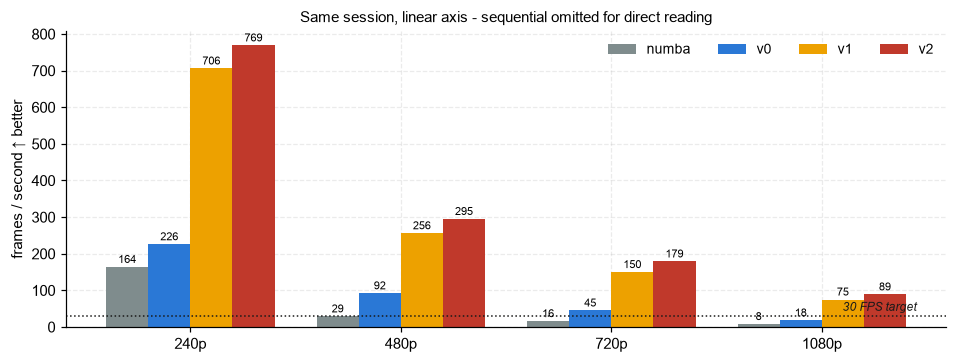

In [18]:
# Same data, excluding sequential (0.05-1.12 FPS), on a linear axis -
# direct values without requiring familiarity with a log scale.
RF = REALFOOTAGE_T4
xs = np.arange(len(RF["tiers"])); w = .2
fig, ax = plt.subplots(figsize=(8.8, 3.4))
for i, (v, col) in enumerate((("numba", "#7f8c8d"), ("v0", C["v0"]),
                              ("v1", C["v1"]), ("v2", C["v2"]))):
    b = ax.bar(xs + (i - 1.5) * w, RF[v]["fps"], w, label=v, color=col)
    ax.bar_label(b, fmt="%.0f", fontsize=7.5, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(3.45, 44, "30 FPS target", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(xs); ax.set_xticklabels(RF["tiers"])
ax.set_ylabel("frames / second ↑ better")
ax.set_title("Same session, linear axis - sequential omitted for direct reading", fontsize=10)
ax.legend(frameon=False, fontsize=9, ncols=4)
plt.tight_layout(); plt.show()

- **How to read:** FPS on the real clip uses a log scale so 0.05 and 769 fit on one axis. All five implementations were measured in the same session to reduce environmental variation. The upper log-scale figure includes Sequential, while the linear figure below shows the same data without Sequential for direct reading.
- **Look for:** v2 sustains 89 FPS at 1080p, while Sequential Python reaches only 0.05 FPS on the exact same frames. The gap is not caused by easier synthetic data.
- **Conclusion:** The optimization ladder holds with a decoder and real footage. Both v1 and v2 exceed 30 FPS at every size, while v0 no longer meets the target at 1080p.

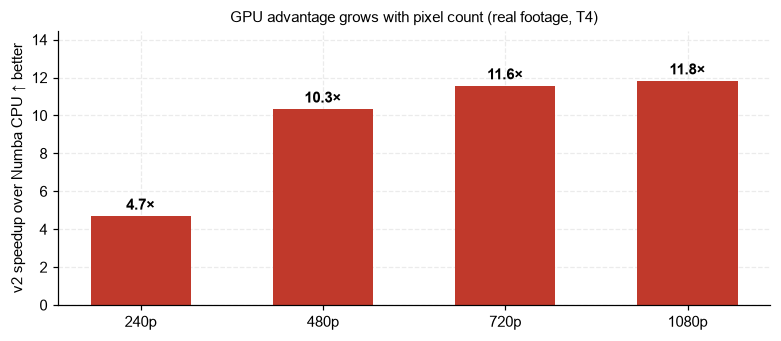

**▸ 11.8× over the compiled CPU at 1080p - and 887× over Sequential Python at 480p, though Numba CPU is the fair baseline (RESULTS-T4 §3).**

In [19]:
# What did the GPU actually buy? v2 vs the compiled CPU baseline, same real
# footage, same protocol - computed live from the recorded table above.
RF = REALFOOTAGE_T4
sp = [n / v for n, v in zip(RF["numba"]["ms"], RF["v2"]["ms"])]
fig, ax = plt.subplots(figsize=(7.2, 3.2))
b = ax.bar(RF["tiers"], sp, .55, color=C["v2"])
ax.bar_label(b, labels=[f"{s:.1f}×" for s in sp], fontsize=10, fontweight="bold", padding=2)
ax.set_ylabel("v2 speedup over Numba CPU ↑ better")
ax.set_title("GPU advantage grows with pixel count (real footage, T4)", fontsize=10)
ax.set_ylim(0, max(sp) * 1.22)
plt.tight_layout(); plt.show()

take(f"{sp[-1]:.1f}× over the compiled CPU at 1080p - and 887× over Sequential "
     "Python at 480p, though Numba CPU is the fair baseline (RESULTS-T4 §3).")

- **How to read:** Each bar shows how many times faster v2 is than the compiled CPU baseline at each resolution. The shared measurement procedure makes the ratio reflect the GPU benefit.
- **Look for:** Speedup rises steadily from 4.7× at 240p to 11.8× at 1080p. This trend follows the increase in pixel count and available parallelism.
- **Conclusion:** The GPU advantage grows with pixel count and peaks where the real-time requirement is hardest. Fixed costs are amortized more effectively at higher resolutions.

### 3.6 · Where the Time Goes

The chart breaks down stages in all three versions. The blue section shrinks from v0→v1 when ingest moves to the device, while the gray section shrinks from v1→v2 through tiling. **The red section is nearly unchanged:** this is the flood fill analyzed in §2.6.

At 1080p, ingest falls from 23.21 → 1.65 ms when moving from v0→v1. The reduction comes mainly from host work being *removed*, because the new device conversion kernel costs only 0.184 ms. Thus, the chart identifies not only which stage becomes faster but also the source of the reduction.

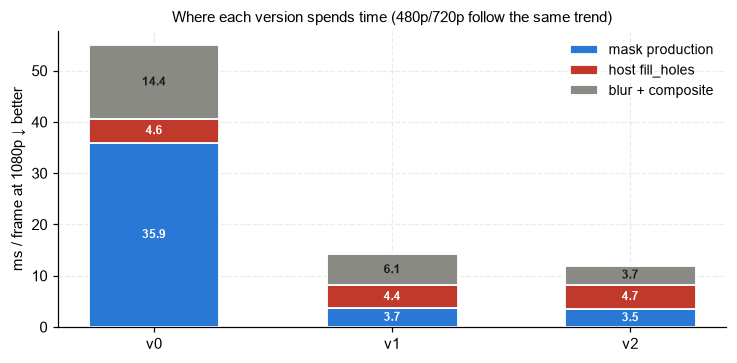

**▸ At 1080p, v2's largest individual stage is now host flood fill - 39.7%. The next opportunity is CUDA streams, not faster kernels.**

In [20]:
stage_cols = {"mask production": C["v0"], "host fill_holes": C["v2"],
              "blur + composite": C["muted"]}
stage_labels = {"mask production": "mask production", "host fill_holes": "host fill_holes",
                "blur + composite": "blur + composite"}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
bottom = np.zeros(3)
for stage, col in stage_cols.items():
    vals = [PERSTAGE[v][stage][2] for v in ("v0", "v1", "v2")]   # [2] = 1080p
    ax.bar(np.arange(3), vals, .55, bottom=bottom, color=col, label=stage_labels[stage],
           edgecolor="white", linewidth=1.2)
    for xi, (v, b0) in enumerate(zip(vals, bottom)):
        ax.text(xi, b0 + v/2, f"{v:.1f}", ha="center", va="center", fontsize=8,
                fontweight="bold", color="white" if col != C["muted"] else C["ink"])
    bottom += np.array(vals)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(["v0", "v1", "v2"])
ax.set_ylabel("ms / frame at 1080p ↓ better")
ax.set_title("Where each version spends time (480p/720p follow the same trend)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

tot = sum(v[2] for v in PERSTAGE["v2"].values())
take(f"At 1080p, v2's largest individual stage is now host flood fill - "
     f"{PERSTAGE['v2']['host fill_holes'][2]/tot:.1%}. The next opportunity is CUDA streams, not faster kernels.")

- **How to read:** Each bar is the time to process one 1080p frame in one version and is divided by pipeline stage. A lower total height means earlier frame completion.
- **Look for:** model+ingest (blue) and blur (gray) shrink from v0 to v2, while host flood fill (red) remains near ≈4.7 ms in all three. The bottleneck therefore moves to the red section.
- **Conclusion:** Fill now takes 39.7% of v2 frame time. The next opportunity is to overlap this stage with CUDA streams. Making kernels faster is no longer sufficient because kernels no longer dominate alone.

### 3.7 · End-to-End Result

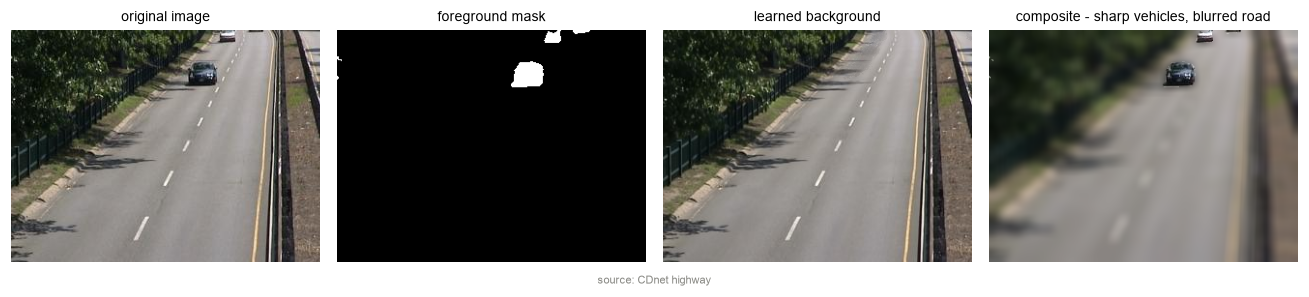

In [21]:
from utils.post_processing import background_blur
from settings import BLUR_KSIZE, BLUR_SIGMA

frames, src = load_sequence(600)
h, w = frames[0].shape[:2]
m = GMM_Mask_Numba(h, w)
for bgr in frames:
    mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
refined = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
out = background_blur(bgr, refined, BLUR_KSIZE, BLUR_SIGMA)
bg  = cv2.cvtColor(m.background_image(), cv2.COLOR_YCrCb2RGB)  # model was fed YCrCb

fig, ax = plt.subplots(1, 4, figsize=(12, 2.7))
for a, (t, im) in zip(ax, [("original image", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
                           ("foreground mask", refined),
                           ("learned background", bg),
                           ("composite - sharp vehicles, blurred road",
                            cv2.cvtColor(out, cv2.COLOR_BGR2RGB))]):
    a.imshow(im, cmap=None if im.ndim == 3 else "gray")
    a.set_title(t, fontsize=9); a.axis("off")
fig.suptitle(f"source: {src}", fontsize=7.5, y=.02, color=C["muted"])
plt.tight_layout(); plt.show()

- **How to read:** The four images show the input, foreground mask, background learned by the model, and final composite frame for one frame passing through the full pipeline. This layout exposes both intermediate state and output.
- **Look for:** The mask retains vehicles, the learned background represents the static scene, and the composite blurs only the road and background. Vehicle edges remain sharp.
- **Conclusion:** The product works end to end as intended. Vehicles remain sharp, the road is blurred, and the final result is consistent with the intermediate steps.

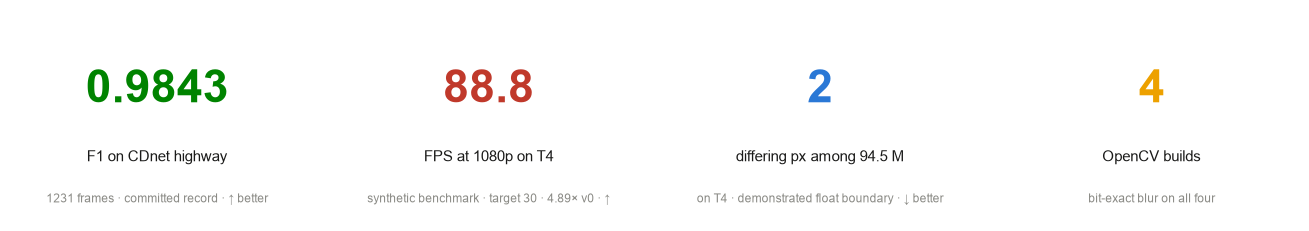

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.2))
tiles = [("0.9843", "F1 on CDnet highway", "1231 frames · committed record · ↑ better", C["good"]),
         ("88.8", "FPS at 1080p on T4", "synthetic benchmark · target 30 · 4.89× v0 · ↑",   C["v2"]),
         ("2", "differing px among 94.5 M", "on T4 · demonstrated float boundary · ↓ better", C["v0"]),
         ("4", "OpenCV builds", "bit-exact blur on all four",                 C["v1"])]
for a, (big, label, sub, col) in zip(axes, tiles):
    a.axis("off")
    a.text(.5, .62, big, ha="center", va="center", fontsize=30, fontweight="bold", color=col)
    a.text(.5, .30, label, ha="center", va="center", fontsize=10, color=C["ink"])
    a.text(.5, .10, sub, ha="center", va="center", fontsize=8, color=C["muted"])
plt.tight_layout(); plt.show()

## 4 · Discussion

### 4.1 · Our Predictions: Five Wrong out of Six

All six predictions are preserved exactly as recorded in `RESULTS-T4.md` §8, written before the benchmark ran. The notable part: of the 5 misses, **3 turned out BETTER than predicted** - the team underestimated the benefit of its own optimizations.

| Prediction (written first) | Expected | Measured | Outcome vs expectation |
|---|---|---|---|
| Ingest + blur saving @1080p | 4-8 ms | ~34 ms | **better by 4-8×** - saved far more |
| Bus traffic reduction | -38.5% | -52.9% | **better** - deeper cut than expected |
| Tiled vs naive blur | *"probably close to naive"* | **2.36× faster** | **better** - tiling won clearly |
| Bottleneck after the change | host `fill_holes` | confirmed, 39.7% @1080p | **correct** |
| Host blur + composite @1080p | 4-8 ms | 13.7 ms | worse - host costlier than expected |
| GPU blur kernels @1080p | 0.2-0.4 ms | 1.55 ms | worse - kernels costlier than expected |

**Three results beat expectations, one call was right, two underestimated host and kernel cost.** The two bad misses are exactly what redirected the optimization toward the host - even the wrong predictions steered the right decision. Lesson: intuition misses in both directions, so every decision needs a measurement.

The tiling result surprised us most. We had assumed that the L2 layout already provided enough reuse, but shared-memory tiles delivered **2.36×** across three resolutions and two measurement procedures. Recording the prediction first made the error explicit and forced us to explain the benefit through data reuse instead of merely reporting a favorable number.

### 4.2 · Lessons Learned

- **The host, not arithmetic, is the bottleneck.** Removing host work produces 76% of the ingest savings. Profiling identifies better optimization targets than guessing from FLOPs.
- **Q8 fixed-point arithmetic (integers with a fixed scale) makes device blur bit-exact.** This is a correctness gain because the result matches OpenCV across every tested build.
- **Separately validated integer YCrCb conversion enables 3 B/px uploads.** This is a transfer gain because frames no longer need float conversion before crossing the bus.
- **Some stages should remain on the CPU.** Flood fill requires 593 dependent passes (`bench_fill.py`). GrabCut adds +2.1 F1 but costs ~141× more, so it was rejected. The measurement was made at `aa4dfb7` and is not reproducible from this checkout. These results show that both quality and parallelism must be considered.

## 5 · Conclusion

This notebook studies one algorithm through five implementations and tests every claim. Quality reaches **F1 0.9843** on CDnet highway. Throughput reaches **88.8 FPS** on synthetic data and **89 FPS** on real 1080p footage. These results meet both proposal goals: 30 FPS and >20× over Sequential Python, with 887× measured. The GPU-vs-CPU difference is bounded by **2 demonstrated float-boundary pixels among 94.5 M**. Speedup comes mainly from moving less data, not simply from computing faster.

### 5.1 · Limitations
- Floating-point differences across compilers: bounded at 2 px of 94.5 M, both proven boundary cases - but this is an inherent limit of the float32 model, not reducible to zero.
- No labeled 1080p dataset exists, so quality is scored only at 320×240; the 1080p numbers are throughput, not quality.
- Timings vary across sessions on shared Colab GPUs (e.g. v2 at 1080p: 88.8 vs 89 FPS between two sessions).
- CUDASIM only checks logic; two bugs surfaced only on real hardware - a green simulator suite is necessary but not sufficient.

### 5.2 · Future Work

- **Pinned (page-locked) buffers + CUDA streams (L4):** This direction overlaps host flood fill with ingest for the next frame. Fill is now the largest individual stage, so profiling identifies this as an appropriate next step. It is **not an achieved result**.
- **Fused separable blur:** This direction is valid because blur has no side effects, so halo recomputation is safe. However, it has not been measured. The two blur kernels take ≈1.55 ms out of 11.07 ms at 1080p, so the maximum gain is limited.
- A labeled 1080p dataset would allow quality evaluation at the same resolution used for throughput.

**References & data sources** <br>
*Zivkovic 2004 · Stauffer & Grimson 1999 · Wang et al., CDnet 2014* <br>
*OpenCV `bgfg_gaussmix2.cpp`, `smooth.simd.hpp`* <br>
*Measurements: Colab T4 - `RESULTS-T4.md` · quality record: `benchmarks/records/eval_highway_full.txt`*